In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy import stats


#### Defining useful functions

In [38]:
def read_csv(filename):
    """Read CSV from Waveforms"""
    dat = np.genfromtxt(filename, delimiter=",", skip_header=13, names=True)
    time = dat["Time_s"]
    voltage = dat["Channel_1_V"]
    return time, voltage


def find_start(time, voltage, show_plot=True):
    """Find timing of ball crossings"""
    threshold = 2.5  # Voltage threshold to detect crossing taken at aproximately the midpoint of the peaks
    crossings = np.where((voltage[:-1] < threshold) & (voltage[1:] >= threshold))[0]
    t_pass = time[crossings]
    t_pass_sigma = np.std(np.diff(t_pass)) / np.sqrt(len(t_pass) - 1)
    if show_plot:
        plt.plot(time, voltage, label="Waveform")
        plt.axhline(y=threshold, color="r", linestyle="--", label="Threshold")
        plt.scatter(t_pass, voltage[crossings], color="g", label="Crossings")
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.title("Waveform with Detected Crossings")
        plt.legend()
        plt.show()

    return t_pass, t_pass_sigma


def acc_func(t, s0, v0, a):
    """Position as a function of time with constant acceleration"""
    return s0 + v0 * t + 0.5 * a * t**2


def acc_fit(t_data, x_data, x_sigma):
    """Fit position data to constant acceleration model"""
    least_squares = LeastSquares(t_data, x_data, x_sigma, acc_func)

    # Create Minuit object with initial parameter guess
    m = Minuit(least_squares, a=1.0, v0=0, s0=0)  # Initial guess for acceleration

    # Perform the fit
    m.migrad()

    # Print results
    print(m.params)
    print(f"Best fit acceleration: {m.values['a']:.4f} ± {m.errors['a']:.4f}")

    # Optional: Check fit quality
    if m.valid:
        print(f"Chi-square / ndf: {m.fval:.2f} / {len(t_data) - 3}")
    return m.values, m.errors, m.fval

### Loading gate positions and finding the acceleration from a fit

In [39]:
# Loading x-position data
excel_path = "C:\\Users\\jeppe\\AppStatLocal\\Project_Folder\\Project\\BallOnIncline\\Ball_data\\BallOnIncline_Group1_data.xlsx"
incline_length = pd.read_excel(
    excel_path, sheet_name="hældning_længder", skiprows=0, usecols="B:G"
)
mean_gateposition = []
sigma_gateposition = []
for i in range(5):
    length = np.mean(
        incline_length[f"mål_{i + 1}"].values - incline_length["åbning"].values
    )
    mean_gateposition.append(length)
    sigma = np.std(
        incline_length[f"mål_{i + 1}"].values - incline_length["åbning"].values, ddof=1
    ) / np.sqrt(len(incline_length[f"mål_{i + 1}"].values))
    sigma_gateposition.append(sigma)
mean_gateposition = np.array(mean_gateposition) / 100  # Convert to meters
sigma_gateposition = np.array(sigma_gateposition) / 100  # Convert to meters
print("Mean gate positions:", np.array(mean_gateposition))
print("Sigma gate positions:", np.array(sigma_gateposition))


Mean gate positions: [0.15112 0.26478 0.41502 0.5634  0.7213 ]
Sigma gate positions: [0.00023324 0.00056427 0.00038131 0.00018708 0.00046368]


<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
C:\Users\jeppe\AppData\Local\Temp\ipykernel_20592\1150069052.py:28: SyntaxWarning: invalid escape sequence '\c'
  title=f"$\chi^2$ / Ndof : {chi2:.2f} / {len(t_pass) - 3} \np = {stats.chi2.sf(chi2, len(t_pass) - 3):.2f}",


File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_1.csv, Crossing Times: [0.98128 1.1294  1.28494 1.41196 1.53072], Sigma: 0.007496522527145499
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.157   │   0.008   │            │            │         │         │       │
│ 1 │ v0   │  -0.675   │   0.014   │            │            │         │         │       │
│ 2 │ a    │   1.364   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3642 ± 0.0112
Chi-square / ndf: 2.18 / 2


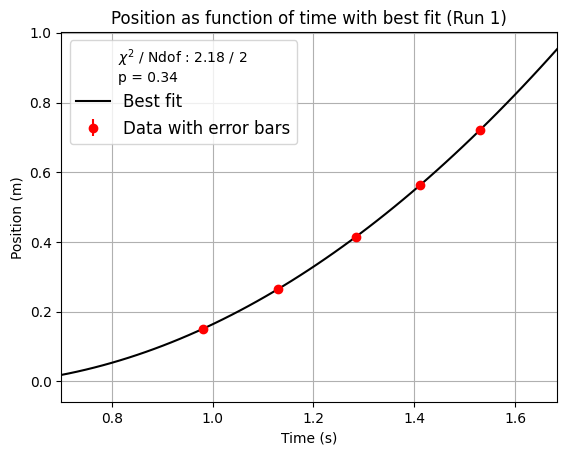

File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_2.csv, Crossing Times: [1.59348 1.74112 1.8963  2.02298 2.1416 ], Sigma: 0.007450021812048637
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.825   │   0.018   │            │            │         │         │       │
│ 1 │ v0   │  -1.512   │   0.020   │            │            │         │         │       │
│ 2 │ a    │   1.367   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3668 ± 0.0112
Chi-square / ndf: 2.81 / 2
File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_3.csv, Crossing T

In [40]:
# looping over time data and fitting to find acceleration
a_array = []
a_sigma_array = []
for i in range(10):
    filename = f"C:\\Users\\jeppe\\AppStatLocal\\Project_Folder\\Project\\BallOnIncline\\Ball_data\\BallIncline_{i + 1}.csv"
    time, voltage = read_csv(filename)
    t_pass, t_pass_sigma = find_start(time, voltage, show_plot=False)
    print(f"File: {filename}, Crossing Times: {t_pass}, Sigma: {t_pass_sigma}")
    params, errors, chi2 = acc_fit(t_pass, mean_gateposition, sigma_gateposition)
    if i == 0:
        plt.errorbar(
            t_pass,
            mean_gateposition,
            yerr=sigma_gateposition,
            fmt="o",
            label="Data with error bars",
            c="r",
        )
        plt.xlim(0.7, np.max(t_pass) * 1.1)
        t_fit = np.linspace(0, np.max(t_pass) * 1.1, 100)
        x_fit = acc_func(t_fit, params["s0"], params["v0"], params["a"])
        plt.plot(t_fit, x_fit, label="Best fit", color="black")
        plt.xlabel("Time (s)")
        plt.ylabel("Position (m)")
        plt.title("Position as function of time with best fit (Run 1)")
        plt.grid()
        plt.legend(
            title=f"$\chi^2$ / Ndof : {chi2:.2f} / {len(t_pass) - 3} \np = {stats.chi2.sf(chi2, len(t_pass) - 3):.2f}",
            fontsize=12,
        )
        plt.savefig("BallOnIncline_Fit.png", dpi=300)
        plt.show()

    a_array.append(params["a"])
    a_sigma_array.append(errors["a"])
a_array = np.array(a_array)
print("Accelerations from all trials:", a_array)

File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_rot_1.csv, Crossing Times: [1.28066 1.4291  1.5847  1.71194 1.83104], Sigma: 0.007462762139449448
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.414   │   0.013   │            │            │         │         │       │
│ 1 │ v0   │  -1.074   │   0.017   │            │            │         │         │       │
│ 2 │ a    │   1.356   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3563 ± 0.0112
Chi-square / ndf: 2.19 / 2


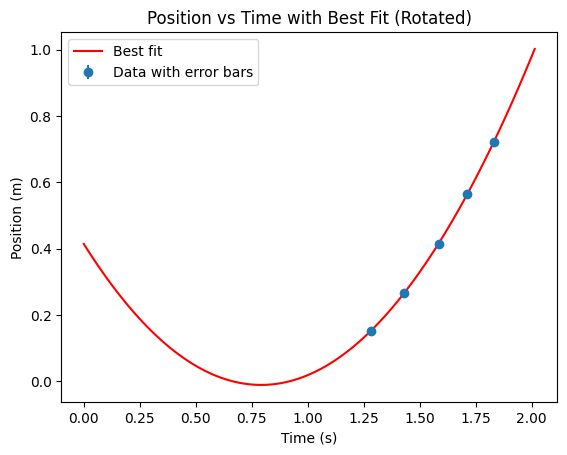

File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_rot_2.csv, Crossing Times: [1.16352 1.31168 1.46706 1.59396 1.71262], Sigma: 0.007501804366284152
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.306   │   0.011   │            │            │         │         │       │
│ 1 │ v0   │  -0.929   │   0.016   │            │            │         │         │       │
│ 2 │ a    │   1.368   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3681 ± 0.0112
Chi-square / ndf: 2.13 / 2
File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_rot_3.csv, Cr

In [41]:
# Finding acceleration in rotated experiments
a_array_rot = []
a_sigma_array_rot = []
for i in range(10):
    filename_rot = f"C:\\Users\\jeppe\\AppStatLocal\\Project_Folder\\Project\\BallOnIncline\\Ball_data\\BallIncline_rot_{i + 1}.csv"
    time_rot, voltage_rot = read_csv(filename_rot)
    t_pass_rot, t_pass_sigma_rot = find_start(time_rot, voltage_rot, show_plot=False)
    print(
        f"File: {filename_rot}, Crossing Times: {t_pass_rot}, Sigma: {t_pass_sigma_rot}"
    )
    params, errors, chi2 = acc_fit(t_pass_rot, mean_gateposition, sigma_gateposition)
    if i == 0:
        plt.errorbar(
            t_pass_rot,
            mean_gateposition,
            yerr=sigma_gateposition,
            fmt="o",
            label="Data with error bars",
        )
        t_fit = np.linspace(0, np.max(t_pass_rot) * 1.1, 100)
        x_fit = acc_func(t_fit, params["s0"], params["v0"], params["a"])
        plt.plot(t_fit, x_fit, label="Best fit", color="red")
        plt.xlabel("Time (s)")
        plt.ylabel("Position (m)")
        plt.title("Position vs Time with Best Fit (Rotated)")
        plt.legend()
        plt.show()
    a_array_rot.append(params["a"])
    a_sigma_array_rot.append(errors["a"])
a_array_rot = np.array(a_array_rot)
print("Accelerations from all trials (Rotated):", a_array_rot)

In [42]:
# I now take the weighted average of the accelerations from both sets of experiments
def weighted_avg_and_std(values, errors):
    """Compute the weighted average and standard deviation."""
    weights = 1 / np.square(errors)
    weighted_avg = np.sum(values * weights) / np.sum(weights)
    weighted_std = np.sqrt(1 / np.sum(weights))
    return weighted_avg, weighted_std

In [43]:
print("Calculating weighted averages...")
a_avg, a_std = weighted_avg_and_std(a_array, a_sigma_array)
a_rot_avg, a_rot_std = weighted_avg_and_std(a_array_rot, a_sigma_array_rot)
print(f"Weighted average acceleration (Normal): {a_avg:.3f} ± {a_std:.3f} m/s²")
print(
    f"Weighted average acceleration (Rotated): {a_rot_avg:.3f} ± {a_rot_std:.3f} m/s²"
)

Calculating weighted averages...
Weighted average acceleration (Normal): 1.366 ± 0.004 m/s²
Weighted average acceleration (Rotated): 1.369 ± 0.004 m/s²


### Angles (both goniometer and trigonometric calculation)


In [44]:
# Loading Goniometer angle data
gonio_angle_data = pd.read_excel(
    excel_path, sheet_name="goniometer_vinkelmål", skiprows=0, usecols="B:C"
)
gonio_angle_data_rot = pd.read_excel(
    excel_path, sheet_name="goniometer_vinkelmål", skiprows=0, usecols="D:E"
)
for i in range(len(gonio_angle_data)):
    print(
        f"Angle measurement {i + 1}: {gonio_angle_data['vinkel_original'][i]} degrees ± {gonio_angle_data['usikkerhed_original'][i]} degrees"
    )
angles_deg = gonio_angle_data["vinkel_original"].values
e_angles_rad = np.deg2rad(gonio_angle_data["usikkerhed_original"].values)
angles_rad = np.deg2rad(angles_deg)
gonio = np.mean(angles_rad)
e_gonio = np.std(angles_rad, ddof=1) / np.sqrt(len(angles_rad))
print("Average angle (Normal):", gonio, "radians ±", e_gonio, "radians")


angles_rot_deg = gonio_angle_data_rot["vinkel_roteret"].values
e_angles_rot_rad = np.deg2rad(gonio_angle_data_rot["usikkerhed_roteret"].values)
angles_rot_rad = np.deg2rad(angles_rot_deg)
gonio_rot = np.mean(angles_rot_rad)
e_gonio_rot = np.std(angles_rot_rad, ddof=1) / np.sqrt(len(angles_rot_rad))
print("Average angle (Rotated):", gonio_rot, "radians ±", e_gonio_rot, "radians")

Angle measurement 1: 14.05 degrees ± 0.05 degrees
Angle measurement 2: 14.1 degrees ± 0.05 degrees
Angle measurement 3: 14.1 degrees ± 0.05 degrees
Angle measurement 4: 14.1 degrees ± 0.05 degrees
Average angle (Normal): 0.24587325837470117 radians ± 0.00021816615649928456 radians
Average angle (Rotated): 0.24150993524471534 radians ± 0.0012015654979501084 radians


In [45]:
# Loading d_rail data, R_ball and calculating angle from length measurements
d_rail = np.array([6.125, 6.00, 6.05, 6.1]) / 1000  # from mm to m
e_d_rail = np.std(d_rail, ddof=1) / np.sqrt(len(d_rail))  # from mm to m
print("Mean d_rail:", np.mean(d_rail), "m ±", e_d_rail, "m")

D_ball = 1 / 100  # from cm to m


Mean d_rail: 0.0060687499999999995 m ± 2.7716947282604297e-05 m


In [46]:
# # Theta trigonometric

# trig_data = pd.read_excel(
#     excel_path, sheet_name="trigonometriske_målinger", skiprows=0, usecols="B:G"
# )
# højde = np.mean(trig_data["Højde"].values)
# længde = np.mean(trig_data["Længde"].values)
# hypo = np.mean(trig_data["Hypotenuse"].values)

# print(f"Højde: {højde} m, Længde: {længde} m, Hypotenuse: {hypo} m")

# theta_trig = np.arccos((længde**2 + hypo**2 - højde**2) / (2 * længde * hypo))

# delta_theta_trig = ((np.mean(a_array) - np.mean(a_array_rot)) * np.sin(theta_trig)) / (
#     (np.mean(a_array) + np.mean(a_array_rot)) * np.cos(theta_trig)
# )
# ###########
# sigma_højde = np.sqrt(np.sum(trig_data["u_højde"].values**2)) / trig_data["u_højde"].size
# sigma_længde = np.sqrt(np.sum(trig_data["u_længde"].values**2)) / trig_data["u_længde"].size
# sigma_hypo = np.sqrt(np.sum(trig_data["u_hypo"].values**2)) / trig_data["u_hypo"].size

# sin_theta = np.sin(theta_trig)

# dtheta_dh = højde / (længde * hypo * sin_theta)
# dtheta_dl = -(længde**2 - hypo**2 + højde**2) / (2 * længde**2 * hypo * sin_theta)
# dtheta_dhypo = -(hypo**2 - længde**2 + højde**2) / (2 * længde * hypo**2 * sin_theta)

# sigma_theta_trig = np.sqrt(
#     (dtheta_dh * sigma_højde) ** 2
#     + (dtheta_dl * sigma_længde) ** 2
#     + (dtheta_dhypo * sigma_hypo) ** 2
# #############
# print(f"Trigonometric theta uncertainty: {sigma_theta_trig}"
# print(f"Trigonometric delta theta: {delta_theta_trig}")

# print(f"Goniometer delta theta: {(np.mean(angles_rad) - np.mean(angles_rot_rad)) / 2}")


In [47]:
from math import sqrt

import sympy as sp

# --- Read data (your existing lines) ---

trig_data = pd.read_excel(
    excel_path, sheet_name="trigonometriske_målinger", skiprows=0, usecols="B:G"
)

# columns used in your snippet: "Højde", "Længde", "Hypotenuse"
h_vals = trig_data["Højde"].values
L_vals = trig_data["Længde"].values
H_vals = trig_data["Hypotenuse"].values

# number of samples (assumed same for each column; if not, compute individually)
n_h = len(h_vals)
n_L = len(L_vals)
n_H = len(H_vals)

# --- Means ---
h_mean = np.mean(h_vals)
L_mean = np.mean(L_vals)
H_mean = np.mean(H_vals)

print(f"Højde (h): {h_mean:.6f} m  (n={n_h})")
print(f"Længde (L): {L_mean:.6f} m  (n={n_L})")
print(f"Hypotenuse (H): {H_mean:.6f} m  (n={n_H})")

# --- Compute theta (same formula you used) ---
# x = (L^2 + H^2 - h^2) / (2 L H)
# theta = arccos(x)
x_val = (L_mean**2 + H_mean**2 - h_mean**2) / (2.0 * L_mean * H_mean)
# clip to [-1,1] to avoid domain errors from rounding
x_val = float(np.clip(x_val, -1.0, 1.0))
theta_trig = np.arccos(x_val)  # radians
print(f"theta_trig = {theta_trig:.8f} rad  = {np.degrees(theta_trig):.6f} deg")

# --- Uncertainty estimation ---
# By default use standard error of the mean for each quantity:
# sigma(h) = std(h_vals) / sqrt(n_h), etc.
# If you already know measurement uncertainties, set these manually below.
sigma_h = np.std(h_vals, ddof=1) / np.sqrt(n_h) if n_h > 1 else 0.0
sigma_L = np.std(L_vals, ddof=1) / np.sqrt(n_L) if n_L > 1 else 0.0
sigma_H = np.std(H_vals, ddof=1) / np.sqrt(n_H) if n_H > 1 else 0.0

print(f"sigma_h (SEM) = {sigma_h:.6e} m")
print(f"sigma_L (SEM) = {sigma_L:.6e} m")
print(f"sigma_H (SEM) = {sigma_H:.6e} m")

# --- Symbolic derivatives (safe and exact) ---
h, L, H = sp.symbols("h L H", positive=True)  # positive helps simplify
x = (L**2 + H**2 - h**2) / (2 * L * H)
theta = sp.acos(x)

# partial derivatives dtheta/dh, dtheta/dL, dtheta/dH
dtheta_dh_sym = sp.diff(theta, h)
dtheta_dL_sym = sp.diff(theta, L)
dtheta_dH_sym = sp.diff(theta, H)

# lambdify for numeric evaluation
dtheta_dh = sp.lambdify((h, L, H), dtheta_dh_sym, "numpy")
dtheta_dL = sp.lambdify((h, L, H), dtheta_dL_sym, "numpy")
dtheta_dH = sp.lambdify((h, L, H), dtheta_dH_sym, "numpy")

# Evaluate derivatives at the mean values
dtheta_dh_val = float(dtheta_dh(h_mean, L_mean, H_mean))
dtheta_dL_val = float(dtheta_dL(h_mean, L_mean, H_mean))
dtheta_dH_val = float(dtheta_dH(h_mean, L_mean, H_mean))

print("Partial derivatives at mean values:")
print(f" dθ/dh = {dtheta_dh_val:.6e} rad/m")
print(f" dθ/dL = {dtheta_dL_val:.6e} rad/m")
print(f" dθ/dH = {dtheta_dH_val:.6e} rad/m")

# Propagate errors (no covariances assumed)
sigma_theta_trig = sqrt(
    (dtheta_dh_val * sigma_h) ** 2
    + (dtheta_dL_val * sigma_L) ** 2
    + (dtheta_dH_val * sigma_H) ** 2
)
delta_theta_trig = ((np.mean(a_array) - np.mean(a_array_rot)) * np.sin(theta_trig)) / (
    (np.mean(a_array) + np.mean(a_array_rot)) * np.cos(theta_trig)
)

print(f"\nUncertainty on theta_trig (σ_theta): {sigma_theta_trig:.6e} rad")
print(f"Which is {np.degrees(sigma_theta_trig):.6e} degrees")
print(f"Trigonometric delta theta: {delta_theta_trig:.6e} rad")

Højde (h): 22.262500 m  (n=2)
Længde (L): 89.775000 m  (n=2)
Hypotenuse (H): 93.025000 m  (n=2)
theta_trig = 0.24158793 rad  = 13.841969 deg
sigma_h (SEM) = 1.250000e-02 m
sigma_L (SEM) = 3.750000e-01 m
sigma_H (SEM) = 7.500000e-02 m
Partial derivatives at mean values:
 dθ/dh = 1.114234e-02 rad/m
 dθ/dL = 2.745174e-04 rad/m
 dθ/dH = -2.931483e-03 rad/m

Uncertainty on theta_trig (σ_theta): 2.798841e-04 rad
Which is 1.603618e-02 degrees
Trigonometric delta theta: -3.237666e-04 rad


In [48]:
# g_trig = (
#     a_avg
#     / (np.sin(theta_trig + delta_theta_trig))
#     * (1 + (2 / 5) * D_ball**2 / ((D_ball) ** 2 - (np.mean(d_rail)) ** 2))
# )
# print("Quick g calculation:", g_trig)


In [49]:
## Finding the error on g from the uncertainties in a, theta, and d_rail
from IPython.core.display import Latex


def lprint(*args, **kwargs):
    """Pretty print arguments as LaTeX using IPython display system

    Parameters
    ----------
    args : tuple
        What to print (in LaTeX math mode)
    kwargs : dict
        optional keywords to pass to `display`
    """
    display(Latex("$$" + " ".join(args) + "$$"), **kwargs)


In [50]:
from sympy import *

# -----------------------------
# 1. Define symbols
# -----------------------------
g_sym, theta, a_reg, a_rot, d_r, D_theta, D_b = symbols(
    r"g, \theta, a_{reg}, a_{rot}, d_{r}, \Delta\theta, D_b"
)

dg, dtheta, da_reg, da_rot, dd_r, dD_theta, dD_b = symbols(
    r"\sigma_{g},\sigma_{\theta}, \sigma_{a_{reg}}, \sigma_{a_{rot}}, \sigma_{d_{r}}, \sigma_{\Delta\theta}, \sigma_{D_b}"
)

# -----------------------------
# 2. Define expressions
# -----------------------------
# Delta theta expression
D_theta_expr = ((a_reg - a_rot) * sin(theta)) / ((a_reg + a_rot) * cos(theta))

# Gravity expression (renamed g_expr to avoid overwriting g_sym)
g_expr = a_reg / (sin(theta + D_theta)) * (1 + (2 / 5) * D_b**2 / (D_b**2 - (d_r) ** 2))

# -----------------------------
# 3. Error propagation for D_theta
# -----------------------------
dD_da_reg = D_theta_expr.diff(a_reg)
dD_da_rot = D_theta_expr.diff(a_rot)
dD_dtheta = D_theta_expr.diff(theta)

sigma_D_theta_expr = sqrt(
    (dD_da_reg * da_reg) ** 2 + (dD_da_rot * da_rot) ** 2 + (dD_dtheta * dtheta) ** 2
)

# -----------------------------
# 4. Error propagation for g
# -----------------------------
dg_da_reg = g_expr.diff(a_reg)
dg_da_rot = g_expr.diff(a_rot)
dg_dtheta = g_expr.diff(theta)
dg_dDtheta = g_expr.diff(D_theta)
dg_dd_r = g_expr.diff(d_r)
dg_dD_b = g_expr.diff(D_b)

sigma_g_expr = sqrt(
    (dg_da_reg * da_reg) ** 2
    + (dg_da_rot * da_rot) ** 2
    + (dg_dtheta * dtheta) ** 2
    + (dg_dDtheta * dD_theta) ** 2  # sigma(Dθ) inserted later
    + (dg_dd_r * dd_r) ** 2
    + (dg_dD_b * dD_b) ** 2
)

# -----------------------------
# 5. Numeric substitution values
# -----------------------------
subs_vals = {
    a_reg: float(a_avg),
    a_rot: float(a_rot_avg),
    theta: float(theta_trig),
    da_reg: float(a_std),  # Check this
    da_rot: float(a_rot_std),  # CHeck this
    dtheta: float(sigma_theta_trig),  # REDO THIS
    D_b: float(D_ball),
    d_r: float(np.mean(d_rail)),
    dd_r: float(e_d_rail),
    dD_b: 0.005 / 100,  # Assume 0.005 cm uncertainty in D_b converted to m
}

# -----------------------------
# 6. Compute σ(Dθ)
# -----------------------------
sigma_D_theta_val = float(sigma_D_theta_expr.subs(subs_vals))

# Insert into substitutions
subs_vals[dD_theta] = sigma_D_theta_val

# -----------------------------
# 7. Compute g and σ(g)
# -----------------------------
# First compute actual Dθ value for g_expr
D_theta_val = float(D_theta_expr.subs(subs_vals))
subs_vals[D_theta] = D_theta_val

g_val = float(g_expr.subs(subs_vals))
sigma_g_val = float(sigma_g_expr.subs(subs_vals))

# -----------------------------
# 8. Print results
# -----------------------------
print(f"D_theta uncertainty σ: {sigma_D_theta_val:.6e} rad")
print(f"D_theta value: {D_theta_val:.6e} rad")
print(f"g (computed): {g_val:.6f} m/s^2")
print(f"sigma_g: {sigma_g_val:.6e} m/s^2")


D_theta uncertainty σ: 4.521752e-04 rad
D_theta value: -3.226053e-04 rad
g (computed): 9.335847 m/s^2
sigma_g: 4.255624e-02 m/s^2


In [51]:
# I now calculate the contribution of single  variables to the total uncertainty in g
a_reg_term = float((dg_da_reg * subs_vals[da_reg]).subs(subs_vals))
a_rot_term = float((dg_da_rot * subs_vals[da_rot]).subs(subs_vals))
theta_term = float((dg_dtheta * subs_vals[dtheta]).subs(subs_vals))
D_theta_term = float((dg_dDtheta * subs_vals[dD_theta]).subs(subs_vals))
d_rail_term = float((dg_dd_r * subs_vals[dd_r]).subs(subs_vals))
D_ball_term = float((dg_dD_b * subs_vals[dD_b]).subs(subs_vals))

print("\nContributions to total uncertainty in g:")
print(f"From a_reg: {np.abs(a_reg_term):.6e} m/s^2")
print(f"From a_rot: {np.abs(a_rot_term):.6e} m/s^2")
print(f"From theta: {np.abs(theta_term):.6e} m/s^2")
print(f"From D_theta: {np.abs(D_theta_term):.6e} m/s^2")
print(f"From d_rail: {np.abs(d_rail_term):.6e} m/s^2")
print(f"From D_ball: {np.abs(D_ball_term):.6e} m/s^2")


Contributions to total uncertainty in g:
From a_reg: 2.422847e-02 m/s^2
From a_rot: 0.000000e+00 m/s^2
From theta: 1.061926e-02 m/s^2
From D_theta: 1.715626e-02 m/s^2
From d_rail: 1.927618e-02 m/s^2
From D_ball: 2.110303e-02 m/s^2
